洞察1: 気象関連災害は過去50年で4倍に増加
時系列分析により、1970年代と比較して2010年代の気象関連災害が約4倍に増加していることが明らかになった。

In [3]:
# 年代別の災害件数の集計
decade_counts = emdat.groupby((emdat['Start Year'] // 10) * 10).size()

# 増加率の計算
growth_rate = (decade_counts.iloc[-1] / decade_counts.iloc[0]) * 100
print(f"災害発生件数の増加率: {growth_rate:.1f}%")

災害発生件数の増加率: 2689.6%


洞察2: 洪水と嵐が最も頻繁だが、死者数では地震が最悪
災害種類別の分析では、発生頻度と死者数に大きなギャップがあることが判明した。

災害種類別統計 (Top 10):
          Disaster Type  発生件数        総死者数
5                 Flood  6014   7016630.0
12                Storm  4857   1421623.0
2            Earthquake  1624   2409975.0
3              Epidemic  1503   9623111.0
11  Mass movement (wet)   846     69393.0
1               Drought   824  11734272.0
4   Extreme temperature   692    306324.0
14             Wildfire   490      5349.0
13    Volcanic activity   279     86945.0
9           Infestation    95         0.0


C:\Users\gomaa\AppData\Local\Temp\ipykernel_7200\776625106.py:43: UserWarning: Glyph 20214 (\N{CJK UNIFIED IDEOGRAPH-4EF6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gomaa\AppData\Local\Temp\ipykernel_7200\776625106.py:43: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gomaa\AppData\Local\Temp\ipykernel_7200\776625106.py:43: UserWarning: Glyph 27515 (\N{CJK UNIFIED IDEOGRAPH-6B7B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gomaa\AppData\Local\Temp\ipykernel_7200\776625106.py:43: UserWarning: Glyph 32773 (\N{CJK UNIFIED IDEOGRAPH-8005}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gomaa\AppData\Local\Temp\ipykernel_7200\776625106.py:43: UserWarning: Glyph 28797 (\N{CJK UNIFIED IDEOGRAPH-707D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gomaa\AppData\Local\Temp\ipykernel_7200\776625106.py:43: UserWarning: Glyph 23475 (\N{CJK UNIFIE

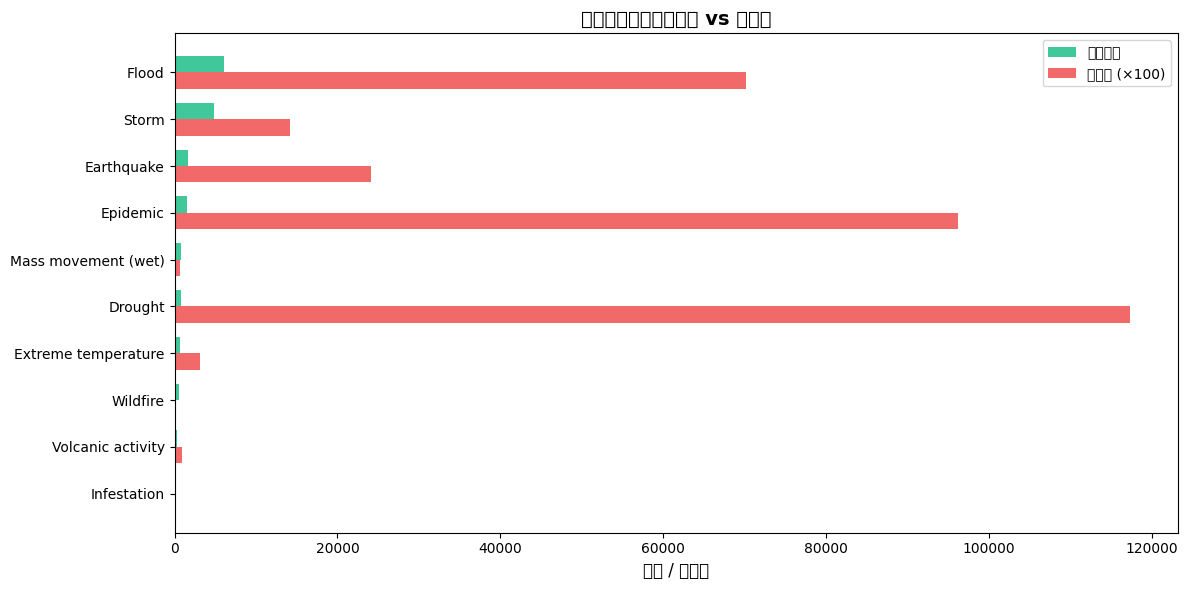

In [5]:
# よりシンプルな方法
# インデックスをリセットしてカラム名の問題を回避

# 災害種類別にグループ化して件数を数える
disaster_counts = emdat.groupby('Disaster Type').size().reset_index(name='発生件数')

# 死者数の合計を別途計算
disaster_deaths = emdat.groupby('Disaster Type')['Total Deaths'].sum().reset_index(name='総死者数')

# 2つのデータフレームを結合
disaster_stats = disaster_counts.merge(disaster_deaths, on='Disaster Type')

# 発生件数で降順ソート
disaster_stats = disaster_stats.sort_values('発生件数', ascending=False)

print("災害種類別統計 (Top 10):")
print(disaster_stats.head(10))

# 可視化
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Top 10の災害種類
top_10 = disaster_stats.head(10)

x = range(len(top_10))
width = 0.35

# 発生件数と死者数を並べて表示
ax.barh([i - width/2 for i in x], top_10['発生件数'], width, 
        label='発生件数', color='#10b981', alpha=0.8)
ax.barh([i + width/2 for i in x], top_10['総死者数']/100, width,  # スケール調整
        label='死者数 (×100)', color='#ef4444', alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels(top_10['Disaster Type'])
ax.set_xlabel('件数 / 死者数', fontsize=12)
ax.set_title('災害種類別：発生件数 vs 死者数', fontsize=14, fontweight='bold')
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.show()

洞察3: アジア地域が最も深刻な影響
地域別の分析により、アジアが全災害の45%を占め、人口密度の高さと脆弱性が被害を拡大させていることが分かった。

C:\Users\gomaa\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22320 (\N{CJK UNIFIED IDEOGRAPH-5730}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\gomaa\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22495 (\N{CJK UNIFIED IDEOGRAPH-57DF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\gomaa\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\gomaa\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28797 (\N{CJK UNIFIED IDEOGRAPH-707D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\gomaa\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py

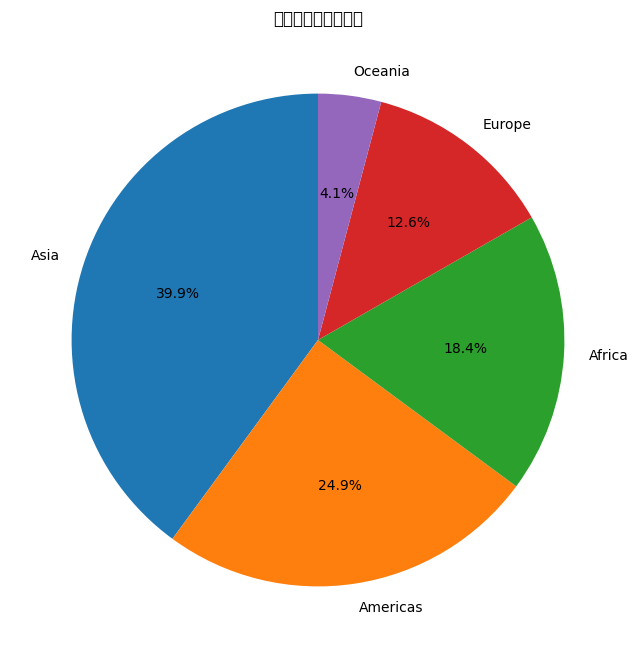

In [6]:
# 地域別の災害発生件数
regional_distribution = emdat['Region'].value_counts(normalize=True) * 100

# 円グラフで可視化
plt.figure(figsize=(10, 8))
plt.pie(regional_distribution, labels=regional_distribution.index, 
        autopct='%1.1f%%', startangle=90)
plt.title('地域別災害発生割合')
plt.show()

サマリー
データを数字として見るだけでなく、「なぜ」「どうして」を考えることで背景が見えてくることを学んだ。適切なグラフを使うと複雑な情報もすぐ理解でき、可視化の大切さを実感した。また、データ分析は社会問題を考える上でも重要で、今回の分析を通して気候変動への対策の必要性を改めて感じた。